<a href="https://colab.research.google.com/github/anandaprida/Ananda-Prida-Yusuf-Septiawan_2112023120013/blob/main/Chapter4_Kelompok5_PengolahanSinyalD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================
# INSTALL LIBRARY
# ================================
!pip install kaggle
!pip install imbalanced-learn

import os
from google.colab import userdata

# ================================
# SETUP KAGGLE API (AUTO FROM SECRET)
# ================================
!mkdir -p ~/.kaggle

try:
    kaggle_json_content = userdata.get('KAGGLE_JSON')

    with open('/root/.kaggle/kaggle.json', 'w') as f:
        f.write(kaggle_json_content)

    !chmod 600 /root/.kaggle/kaggle.json
    print("✅ Kaggle API ready")

except Exception as e:
    print(f"❌ Error: {e}")
    print("Pastikan kamu sudah isi KAGGLE_JSON di Colab Secrets")

# ================================
# DOWNLOAD DATASET
# ================================
dataset_name = "harunshimanto/epileptic-seizure-recognition"

print(f"Downloading {dataset_name} ...")
!kaggle datasets download -d {dataset_name}

# ================================
# UNZIP
# ================================
zip_file = dataset_name.split('/')[-1] + '.zip'

print(f"Unzipping {zip_file} ...")
!unzip -o {zip_file}

print("✅ Dataset siap dipakai")

❌ Error: Secret KAGGLE_JSON does not exist.
Pastikan kamu sudah isi KAGGLE_JSON di Colab Secrets
Dataset URL: https://www.kaggle.com/datasets/harunshimanto/epileptic-seizure-recognition
License(s): other
100% 2.77M/2.77M [00:00<00:00, 169MB/s]

Unzipping epileptic-seizure-recognition.zip ...
Archive:  epileptic-seizure-recognition.zip
  inflating: Epileptic Seizure Recognition.csv  
✅ Dataset siap dipakai


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv('Epileptic Seizure Recognition.csv')

# Lihat isi
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
# 1 = seizure
# selain itu = normal

df['y'] = df['y'].apply(lambda x: 1 if x == 1 else 0)

df['y'].value_counts()

,count
y,
0,9200
1,2300


In [5]:
df = df.drop(columns=['Unnamed'])

In [6]:
X = df.drop(columns=['y'])
y = df['y']

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 1. PCA (Principal Component Analysis)

Mengurangi dimensi data dengan tetap mempertahankan informasi utama (variance).

In [9]:
from sklearn.decomposition import PCA

# buat PCA
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Shape PCA:", X_train_pca.shape)

Shape PCA: (9200, 2)


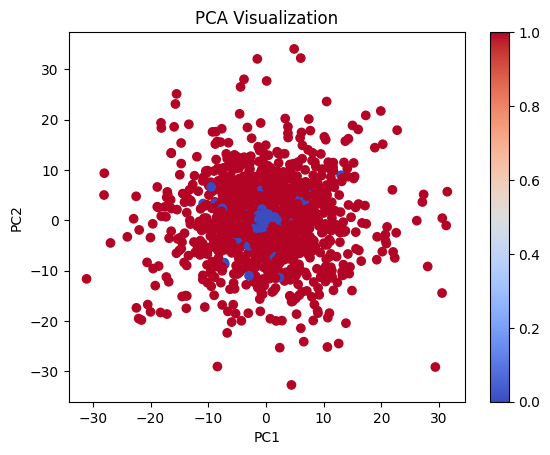

In [10]:
import matplotlib.pyplot as plt

plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='coolwarm')
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

PCA digunakan untuk mereduksi dimensi dari 178 fitur menjadi 2 komponen utama.
Komponen ini menangkap variasi terbesar dari data sehingga informasi penting tetap dipertahankan.

# 2. ICA (Independent Component Analysis)

Memisahkan sinyal menjadi komponen independen.

In [11]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components=2, random_state=42)

X_train_ica = ica.fit_transform(X_train)
X_test_ica = ica.transform(X_test)

print("Shape ICA:", X_train_ica.shape)

Shape ICA: (9200, 2)


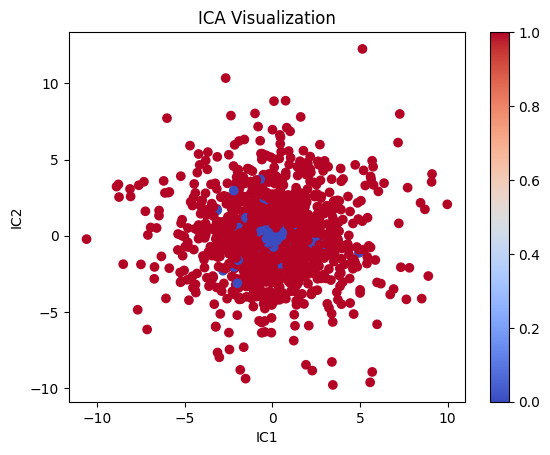

In [12]:
plt.scatter(X_train_ica[:,0], X_train_ica[:,1], c=y_train, cmap='coolwarm')
plt.title("ICA Visualization")
plt.xlabel("IC1")
plt.ylabel("IC2")
plt.colorbar()
plt.show()

ICA digunakan untuk mencari komponen yang saling independen.
Metode ini cocok untuk sinyal seperti EEG karena dapat memisahkan sumber sinyal yang berbeda.

#  3. LDA (Linear Discriminant Analysis)

Maksimalkan pemisahan antar kelas (bukan cuma variance)

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print("Shape LDA:", X_train_lda.shape)

Shape LDA: (9200, 1)


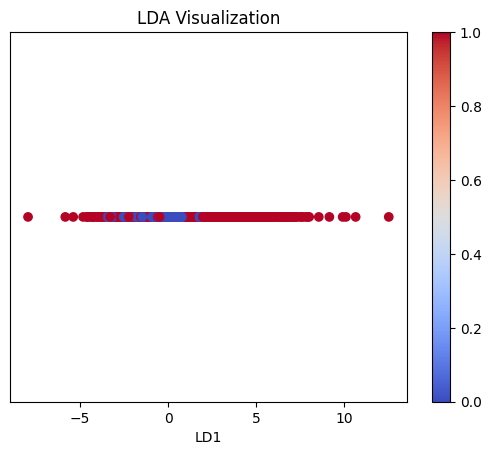

In [14]:
plt.scatter(X_train_lda, [0]*len(X_train_lda), c=y_train, cmap='coolwarm')
plt.title("LDA Visualization")
plt.xlabel("LD1")
plt.yticks([])
plt.colorbar()
plt.show()

LDA digunakan untuk memaksimalkan separasi antara kelas seizure dan non-seizure.
Berbeda dengan PCA, LDA menggunakan informasi label.

# Bandingkan performa PCA vs ICA vs LDA

In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC()

# PCA
model.fit(X_train_pca, y_train)
y_pred_pca = model.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

# ICA
model.fit(X_train_ica, y_train)
y_pred_ica = model.predict(X_test_ica)
acc_ica = accuracy_score(y_test, y_pred_ica)

# LDA
model.fit(X_train_lda, y_train)
y_pred_lda = model.predict(X_test_lda)
acc_lda = accuracy_score(y_test, y_pred_lda)

print("Accuracy PCA:", acc_pca)
print("Accuracy ICA:", acc_ica)
print("Accuracy LDA:", acc_lda)

Accuracy PCA: 0.9434782608695652
Accuracy ICA: 0.9434782608695652
Accuracy LDA: 0.8608695652173913


In [18]:
from imblearn.over_sampling import SMOTE

print("\n" + "="*80)
print("=== RESAMPLING WITH SMOTE ===")
print("="*80)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Shape X_train sebelum resample: {X_train.shape}")
print(f"Shape y_train sebelum resample: {y_train.shape}")
print(f"Shape X_train setelah resample: {X_train_resampled.shape}")
print(f"Shape y_train setelah resample: {y_train_resampled.shape}")

print("\nDistribusi kelas y_train_resampled:")
print(y_train_resampled.value_counts())


=== RESAMPLING WITH SMOTE ===
Shape X_train sebelum resample: (9200, 178)
Shape y_train sebelum resample: (9200,)
Shape X_train setelah resample: (14730, 178)
Shape y_train setelah resample: (14730,)

Distribusi kelas y_train_resampled:
y
1    7365
0    7365
Name: count, dtype: int64



=== FEATURE REDUCTION & BENCHMARK (PCA vs ICA vs LDA) ===

--- Evaluasi Metode: PCA ---


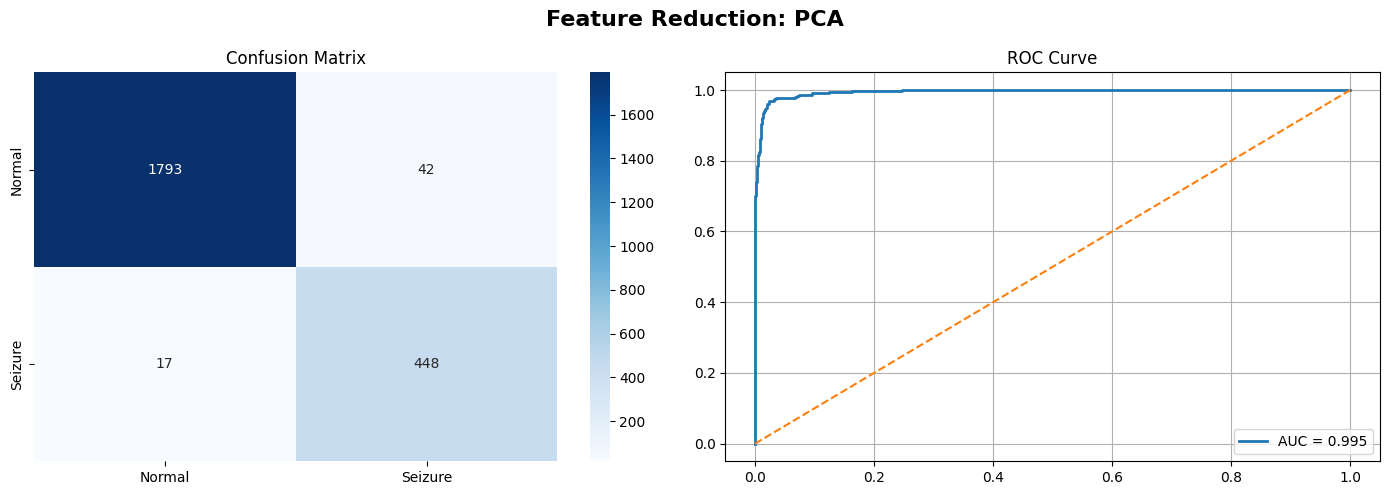


--- Evaluasi Metode: ICA ---


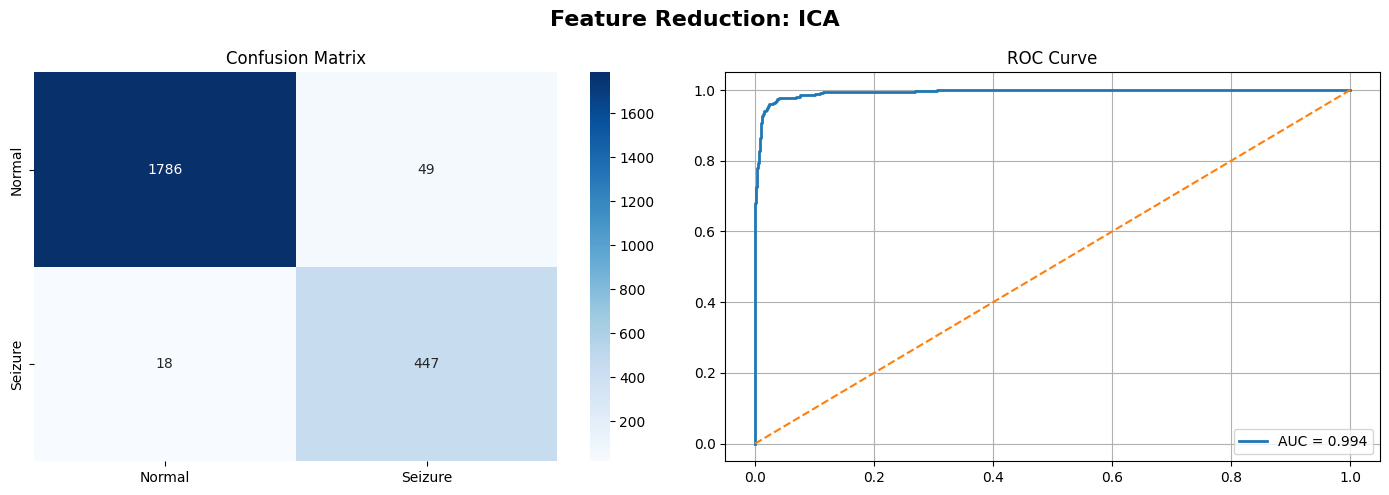


--- Evaluasi Metode: LDA ---


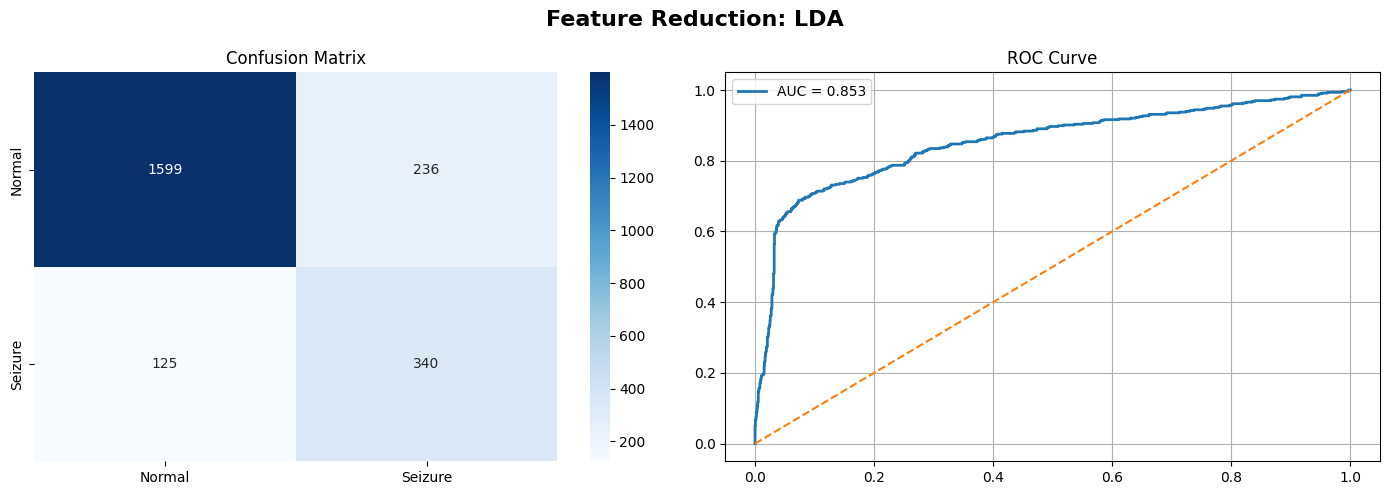


=== PERBANDINGAN AKHIR PCA vs ICA vs LDA ===


,Accuracy,Precision,Recall,F1-Score
PCA,0.974348,0.914286,0.963441,0.938220
ICA,0.970870,0.901210,0.961290,0.930281
LDA,0.843043,0.590278,0.731183,0.653218



=== KESIMPULAN FEATURE REDUCTION ===
Metode terbaik adalah: PCA
F1-Score: 0.938
Recall: 0.963

ANALISIS:
- PCA menang karena mampu menangkap variasi utama data EEG.
- Namun metode ini tidak mempertimbangkan label kelas.


In [20]:
# =====================================================================
# 4. FEATURE REDUCTION + BENCHMARK (PCA vs ICA vs LDA)
# =====================================================================

from sklearn.decomposition import PCA, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Make sure pandas is imported for DataFrame

print("\n" + "="*80)
print("=== FEATURE REDUCTION & BENCHMARK (PCA vs ICA vs LDA) ===")
print("="*80)

# -------------------------------
# REDUCTION METHODS
# -------------------------------
pca = PCA(n_components=20, random_state=42)
ica = FastICA(n_components=20, random_state=42)
lda = LinearDiscriminantAnalysis(n_components=1, solver='eigen', shrinkage='auto')

X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test)

X_train_ica = ica.fit_transform(X_train_resampled)
X_test_ica = ica.transform(X_test)

X_train_lda = lda.fit_transform(X_train_resampled, y_train_resampled)
X_test_lda = lda.transform(X_test)

# -------------------------------
# DATASET CONTAINER
# -------------------------------
reduction_datasets = {
    "PCA": (X_train_pca, X_test_pca),
    "ICA": (X_train_ica, X_test_ica),
    "LDA": (X_train_lda, X_test_lda)
}

# -------------------------------
# MODEL (PAKAI SVM BIAR FAIR)
# -------------------------------
model = SVC(probability=True, kernel='rbf', random_state=42)

reduction_results = {}

# -------------------------------
# LOOP SEMUA METODE
# -------------------------------
for name, (Xtr, Xte) in reduction_datasets.items():

    print(f"\n--- Evaluasi Metode: {name} ---")

    # Train
    model.fit(Xtr, y_train_resampled)

    # Predict
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    reduction_results[name] = [acc, prec, rec, f1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Feature Reduction: {name}', fontsize=16, fontweight='bold')

    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Seizure'],
                yticklabels=['Normal', 'Seizure'], ax=axes[0])
    axes[0].set_title('Confusion Matrix')

    # ROC Curve
    axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0,1],[0,1],'--')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# -------------------------------
# HASIL PERBANDINGAN
# -------------------------------
print("\n=== PERBANDINGAN AKHIR PCA vs ICA vs LDA ===")

reduction_df = pd.DataFrame(
    reduction_results,
    index=['Accuracy', 'Precision', 'Recall', 'F1-Score']
).T

display(reduction_df.sort_values(by='F1-Score', ascending=False))

# -------------------------------
# KESIMPULAN OTOMATIS
# -------------------------------
print("\n" + "="*80)
print("=== KESIMPULAN FEATURE REDUCTION ===")
print("="*80)

best_method = reduction_df['F1-Score'].idxmax()
best_f1 = reduction_df.loc[best_method, 'F1-Score']
best_recall = reduction_df.loc[best_method, 'Recall']

print(f"Metode terbaik adalah: {best_method}")
print(f"F1-Score: {best_f1:.3f}")
print(f"Recall: {best_recall:.3f}\n")

print("ANALISIS:")

if best_method == "PCA":
    print("- PCA menang karena mampu menangkap variasi utama data EEG.")
    print("- Namun metode ini tidak mempertimbangkan label kelas.")

elif best_method == "ICA":
    print("- ICA efektif karena memisahkan sinyal EEG menjadi komponen independen.")
    print("- Cocok untuk data sinyal kompleks seperti aktivitas otak.")

elif best_method == "LDA":
    print("- LDA paling optimal karena memaksimalkan separasi antar kelas.")
    print("- Menggunakan informasi label \u2192 sangat cocok untuk klasifikasi.")


=== FEATURE REDUCTION & BENCHMARK (PCA vs ICA vs LDA) ===

--- Evaluasi Metode: PCA ---


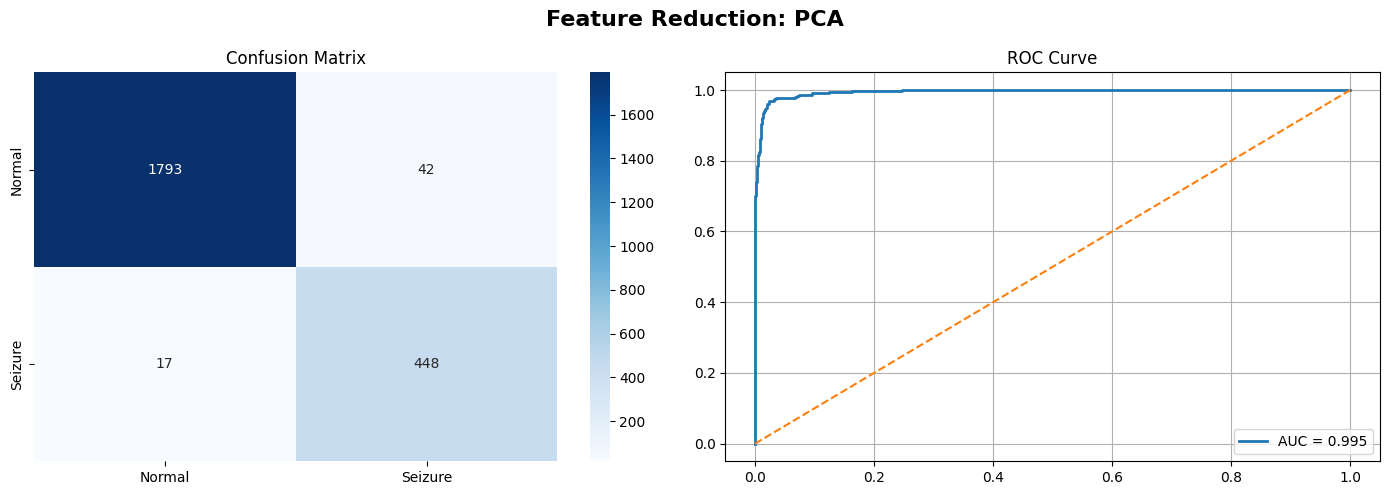


--- Evaluasi Metode: ICA ---


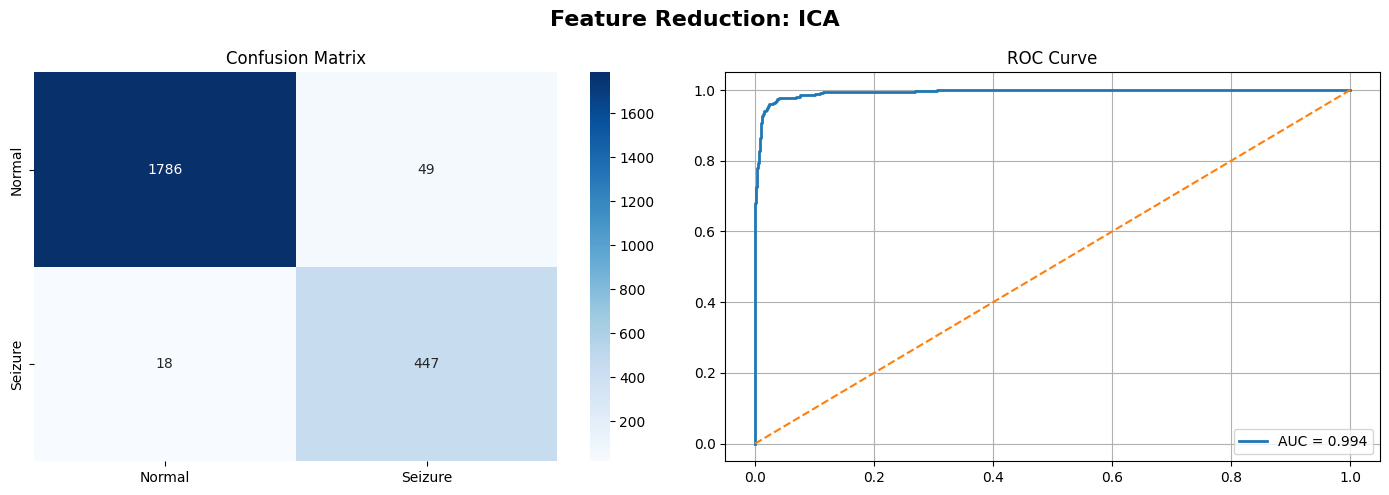


--- Evaluasi Metode: LDA ---


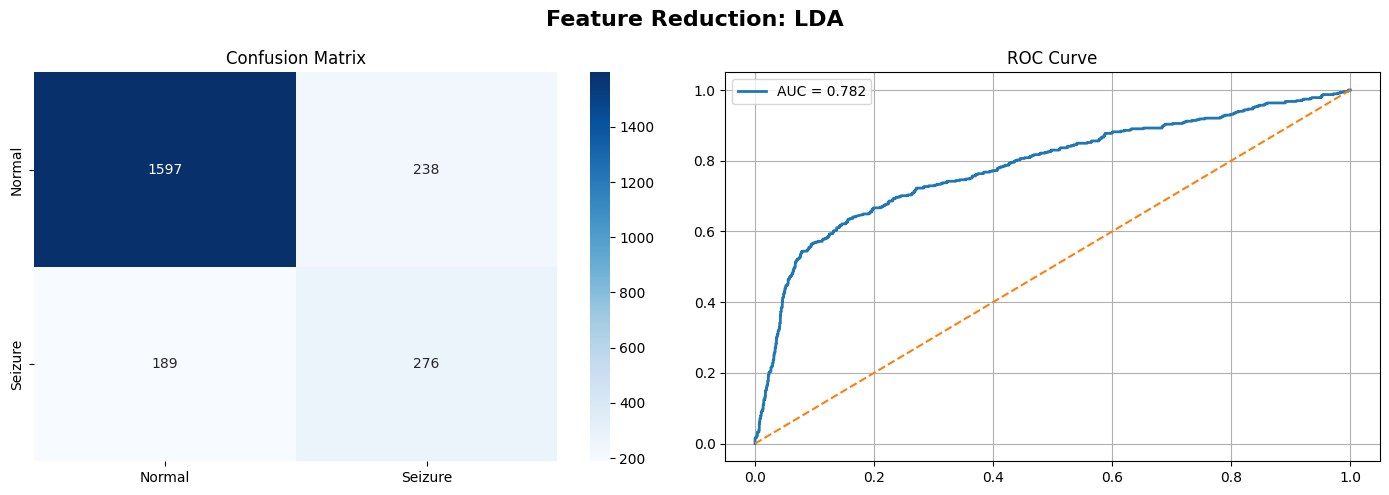


=== PERBANDINGAN AKHIR PCA vs ICA vs LDA ===


,Accuracy,Precision,Recall,F1-Score
PCA,0.974348,0.914286,0.963441,0.938220
ICA,0.970870,0.901210,0.961290,0.930281
LDA,0.814348,0.536965,0.593548,0.563841



=== KESIMPULAN FEATURE REDUCTION ===
Metode terbaik adalah: PCA
F1-Score: 0.938
Recall: 0.963

ANALISIS:
- PCA menang karena mampu menangkap variasi utama data EEG.
- Namun metode ini tidak mempertimbangkan label kelas.


In [21]:
# =====================================================================
# 4. FEATURE REDUCTION + BENCHMARK (PCA vs ICA vs LDA)
# =====================================================================

from sklearn.decomposition import PCA, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Make sure pandas is imported for DataFrame

print("\n" + "="*80)
print("=== FEATURE REDUCTION & BENCHMARK (PCA vs ICA vs LDA) ===")
print("="*80)

# -------------------------------
# REDUCTION METHODS
# -------------------------------
pca = PCA(n_components=20, random_state=42)
ica = FastICA(n_components=20, random_state=42)
lda = LinearDiscriminantAnalysis(n_components=1)

X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test)

X_train_ica = ica.fit_transform(X_train_resampled)
X_test_ica = ica.transform(X_test)

X_train_lda = lda.fit_transform(X_train_resampled, y_train_resampled)
X_test_lda = lda.transform(X_test)

# -------------------------------
# DATASET CONTAINER
# -------------------------------
reduction_datasets = {
    "PCA": (X_train_pca, X_test_pca),
    "ICA": (X_train_ica, X_test_ica),
    "LDA": (X_train_lda, X_test_lda)
}

# -------------------------------
# MODEL (PAKAI SVM BIAR FAIR)
# -------------------------------
model = SVC(probability=True, kernel='rbf', random_state=42)

reduction_results = {}

# -------------------------------
# LOOP SEMUA METODE
# -------------------------------
for name, (Xtr, Xte) in reduction_datasets.items():

    print(f"\n--- Evaluasi Metode: {name} ---")

    # Train
    model.fit(Xtr, y_train_resampled)

    # Predict
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    reduction_results[name] = [acc, prec, rec, f1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Feature Reduction: {name}', fontsize=16, fontweight='bold')

    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Seizure'],
                yticklabels=['Normal', 'Seizure'], ax=axes[0])
    axes[0].set_title('Confusion Matrix')

    # ROC Curve
    axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0,1],[0,1],'--')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# -------------------------------
# HASIL PERBANDINGAN
# -------------------------------
print("\n=== PERBANDINGAN AKHIR PCA vs ICA vs LDA ===")

reduction_df = pd.DataFrame(
    reduction_results,
    index=['Accuracy', 'Precision', 'Recall', 'F1-Score']
).T

display(reduction_df.sort_values(by='F1-Score', ascending=False))

# -------------------------------
# KESIMPULAN OTOMATIS
# -------------------------------
print("\n" + "="*80)
print("=== KESIMPULAN FEATURE REDUCTION ===")
print("="*80)

best_method = reduction_df['F1-Score'].idxmax()
best_f1 = reduction_df.loc[best_method, 'F1-Score']
best_recall = reduction_df.loc[best_method, 'Recall']

print(f"Metode terbaik adalah: {best_method}")
print(f"F1-Score: {best_f1:.3f}")
print(f"Recall: {best_recall:.3f}\n")

print("ANALISIS:")

if best_method == "PCA":
    print("- PCA menang karena mampu menangkap variasi utama data EEG.")
    print("- Namun metode ini tidak mempertimbangkan label kelas.")

elif best_method == "ICA":
    print("- ICA efektif karena memisahkan sinyal EEG menjadi komponen independen.")
    print("- Cocok untuk data sinyal kompleks seperti aktivitas otak.")

elif best_method == "LDA":
    print("- LDA paling optimal karena memaksimalkan separasi antar kelas.")
    print("- Menggunakan informasi label \u2192 sangat cocok untuk klasifikasi.")